# FarmTech Solutions — Parte 3: Perfil Ideal das Culturas
## FIAP IA 2026/1 | Fase 3 Cap 10 | Grupo 45

**Responsável:** Igor | **Branch:** `parte3-IGOR`

---
Esta parte define o "perfil ideal" de solo e clima usando as medianas do dataset, e compara **3 culturas (rice, coffee e banana)**. As culturas escolhidas foram rice, coffee e banana por representarem diferentes condições de solo e clima. O arroz (rice) necessita de alta umidade e grande volume de chuvas, sendo comum em regiões alagadas. O café (coffee) possui grande importância econômica no Brasil e apresenta características climáticas mais equilibradas. Já a banana (banana) se desenvolve melhor em regiões tropicais, com temperaturas e umidade elevadas. Dessa forma, a comparação permite analisar culturas com necessidades agrícolas distintas.


## Setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('produtos_agricolas.csv')
print(f"Dataset carregado: {df.shape[0]} linhas, {df['label'].nunique()} culturas")
df.head()

Dataset carregado: 2200 linhas, 22 culturas


,N,P,K,temperature,humidity,ph,rainfall,label
0,93,19,59,25.713620,92.424861,6.613252,24.183549,muskmelon
1,99,17,42,25.755171,90.687041,6.677987,51.310634,watermelon
2,34,56,49,31.932154,92.972340,6.902555,156.413743,papaya
3,53,67,56,33.077583,88.035813,5.816981,137.743190,papaya
4,14,143,191,20.630108,91.844701,6.073189,116.278481,apple


## 1. Calculando o Perfil Ideal

In [19]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Calcular a mediana de cada variável no dataset completo
# Isso representa o "perfil ideal" — o centro de todas as culturas
perfil_ideal = df[features].median()
print("Perfil ideal:")
print(perfil_ideal)


Perfil ideal:
N              30.000000
P              49.000000
K              31.000000
temperature    25.365282
humidity       79.576299
ph              6.478473
rainfall       95.159007
dtype: float64


## 2. Escolha suas 3 Culturas

In [20]:
# 3 culturas e justifique a escolha (em markdown abaixo)
# Escolhidas: 'rice', 'banana', 'coffee'
culturas_escolhidas = ['rice', 'coffee', 'banana']  # Substitua aqui

perfis = df[df['label'].isin(culturas_escolhidas)].groupby('label')[features].mean()
perfis.loc['perfil_ideal'] = perfil_ideal
print(perfis.round(2))


                  N      P      K  temperature  humidity    ph  rainfall
label                                                                   
banana        99.59  80.13  49.12        27.24     80.12  5.94    106.85
coffee        99.55  28.62  29.59        25.94     57.65  6.78    163.59
rice          79.89  47.17  38.44        23.72     81.92  6.44    234.92
perfil_ideal  30.00  49.00  31.00        25.37     79.58  6.48     95.16


### Por que essas 3 culturas?

> As culturas escolhidas foram rice, coffee e banana por apresentarem características agrícolas e climáticas bastante distintas. O arroz necessita de alta umidade e grande quantidade de chuva, sendo comum em regiões alagadas. O café possui grande relevância econômica no agronegócio brasileiro e apresenta condições de cultivo mais equilibradas. Já a banana se desenvolve melhor em regiões tropicais, com temperaturas elevadas e alta umidade. Dessa forma, a comparação entre essas culturas permite analisar diferentes perfis de solo e clima dentro do dataset.


## 3. Gráfico 6 — Comparação Visual das 3 Culturas vs. Perfil Ideal

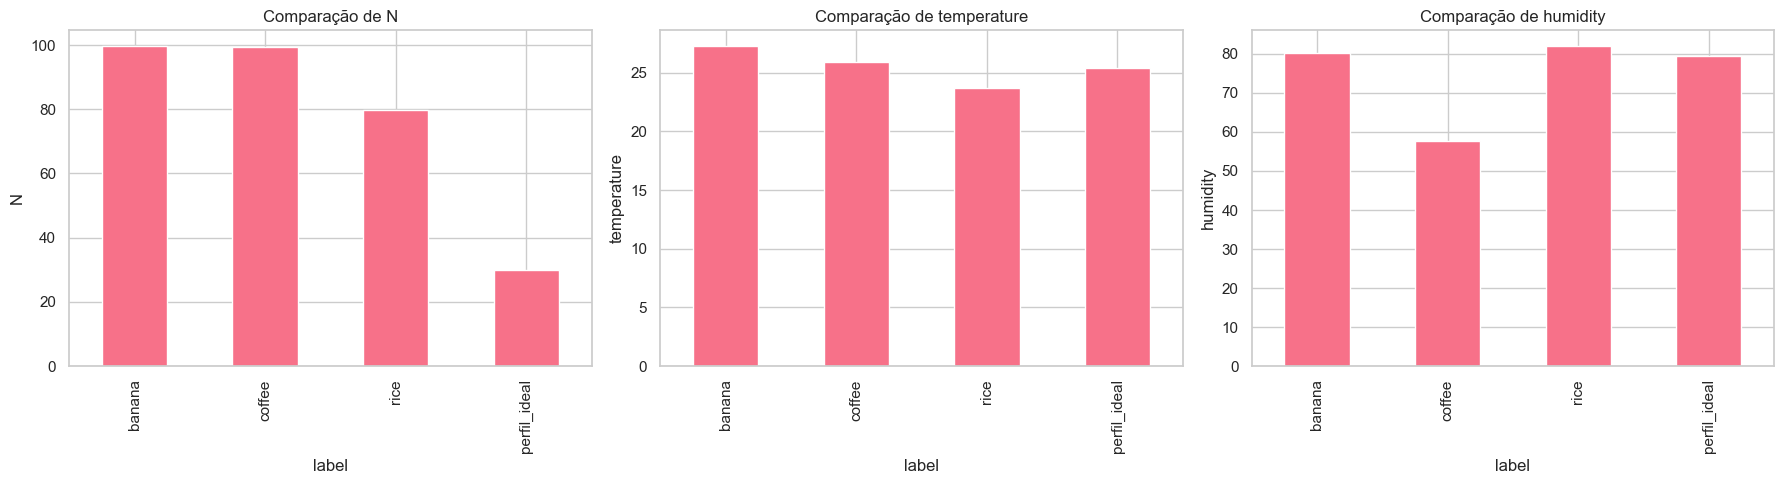

In [21]:
# Criar gráfico de barras comparando as 3 culturas + perfil_ideal
# 3 variáveis diferentes (ex: N, temperature, humidity)

variaveis = ['N', 'temperature', 'humidity']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(variaveis):
    perfis[var].plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Comparação de {var}')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

## 4. Análise Comparativa

### Rice
O arroz apresenta valores acima do perfil ideal principalmente em umidade e volume de chuvas, demonstrando necessidade de ambientes muito úmidos para um bom desenvolvimento. Em algumas variáveis de nutrientes, os valores ficam próximos da média geral. Isso indica que o arroz depende fortemente de disponibilidade hídrica.

### Coffee
O café apresenta temperatura e pH próximos ao perfil ideal, mostrando um perfil mais equilibrado. Em algumas variáveis de nutrientes, os valores ficam abaixo da média, indicando que o café consegue se adaptar bem a diferentes condições de solo e clima.

### Banana
A banana apresenta temperatura, umidade e volume de chuvas acima do perfil ideal, demonstrando preferência por regiões tropicais e úmidas. Já algumas concentrações de nutrientes ficam abaixo da média. Isso mostra que a banana necessita principalmente de calor e alta umidade para melhor produtividade.